In [1]:
import os
import re
import unicodedata

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

/Users/affiliation/Data_science/Wine-Classifier/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/affiliation/Data_science/Wine-Classifier/.venv/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
CONFIG = {
    "model_name":        "bert-base-uncased",
    "max_len":           128,
    "batch_size":        16,
    "num_epochs":        3,
    "lr":                2e-5,
    "num_classes":       3,
    "test_size":         0.2,
    "random_state":      42,
    "domain_words":      ['malbec','tannins','oak','champagne','citrus',
                          'sauvignon','pinot','merlot','barrique','fermentation'],
    "mlflow_experiment": "wine-bert-classifier",
}

## Чтение данных

In [3]:
df_full = pd.read_csv("data/WineDataset.csv")
df_full 

,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
0,"The Guv'nor, Spain",We asked some of our most prized winemakers wo...,£9.99 per bottle,75CL,Tempranillo,NaN,Natural Cork,Spain,10.5,"Vanilla, Blackberry, Blackcurrant",per bottle,Red,ABV 14.00%,NaN,Rich & Juicy,NV,NaN
1,Bread & Butter 'Winemaker's Selection' Chardon...,This really does what it says on the tin. It’s...,£15.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,USA,10.1,"Vanilla, Almond, Coconut, Green Apple, Peach, ...",per bottle,White,ABV 13.50%,California,Rich & Toasty,2021,Napa Valley
2,"Oyster Bay Sauvignon Blanc 2022, Marlborough",Oyster Bay has been an award-winning gold-stan...,£12.49 per bottle,75CL,Sauvignon Blanc,NaN,Screwcap,New Zealand,9.8,"Tropical Fruit, Gooseberry, Grapefruit, Grass,...",per bottle,White,ABV 13.00%,Marlborough,Crisp & Zesty,2022,NaN
3,Louis Latour Mâcon-Lugny 2021/22,We’ve sold this wine for thirty years – and fo...,£17.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,France,10.1,"Peach, Apricot, Floral, Lemon",per bottle,White,ABV 13.50%,Burgundy,Ripe & Rounded,2022,Macon
4,Bread & Butter 'Winemaker's Selection' Pinot N...,Bread & Butter is that thing that you can coun...,£15.99 per bottle,75CL,Pinot Noir,NaN,Natural Cork,USA,10.1,"Smoke, Black Cherry, Cedar, Raspberry, Red Fruit",per bottle,Red,ABV 13.50%,California,Smooth & Mellow,2021,Napa Valley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1285,"Vouvray Sec 'Expresion de Silex' 2020/21, Loire",Although Denis Meunier is only in his late 20s...,£11.99 per bottle,75CL,Chenin Blanc,NaN,Natural Cork,France,9.4,"Quince, Green Apple, Lemon, Pear",per bottle,White,ABV 12.50%,Loire,Aromatic & Floral,2021,Vouvray
1286,"Waimea Estates Pinot Noir Rosé 2021, Nelson",Waimea’s vineyards are less than 1km from the ...,£13.99 per bottle,75CL,Pinot Noir,NaN,Screwcap,New Zealand,9.8,"Floral, Raspberry, Red Cherry, Strawberry",per bottle,Rosé,ABV 13.00%,Nelson,Delicate & Dry,2021,NaN
1287,Wakefield 'Visionary' Cabernet Sauvignon 2010,Made from the very best fruit nourished by 40-...,£85.00 per bottle,75CL,Cabernet Sauvignon,NaN,Screwcap,Australia,10.1,"Vanilla, Blackberry, Blackcurrant, Cedar, Euca...",per bottle,Red,ABV 13.50%,South Australia,Savoury & Full Bodied,2010,Clare Valley
1288,Yalumba 'The Menzies' Cabernet Sauvignon 2015/...,"In 1961, Sir Robert Menzies said that Yalumba'...",£37.99 per bottle,75CL,Cabernet Sauvignon,NaN,Natural Cork,Australia,10.9,"Black Plum, Blackcurrant, Vanilla",per bottle,Red,ABV 14.50%,South Australia,Savoury & Full Bodied,2016,Coonawarra


In [4]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      1290 non-null   object 
 1   Description                1286 non-null   object 
 2   Price                      1290 non-null   object 
 3   Capacity                   1290 non-null   object 
 4   Grape                      1275 non-null   object 
 5   Secondary Grape Varieties  488 non-null    object 
 6   Closure                    1279 non-null   object 
 7   Country                    1284 non-null   object 
 8   Unit                       1281 non-null   float64
 9   Characteristics            1253 non-null   object 
 10  Per bottle / case / each   1290 non-null   object 
 11  Type                       1285 non-null   object 
 12  ABV                        1281 non-null   object 
 13  Region                     1124 non-null   objec

In [5]:
df = df_full[['Description', 'Type']]
df

,Description,Type
0,We asked some of our most prized winemakers wo...,Red
1,This really does what it says on the tin. It’s...,White
2,Oyster Bay has been an award-winning gold-stan...,White
3,We’ve sold this wine for thirty years – and fo...,White
4,Bread & Butter is that thing that you can coun...,Red
...,...,...
1285,Although Denis Meunier is only in his late 20s...,White
1286,Waimea’s vineyards are less than 1km from the ...,Rosé
1287,Made from the very best fruit nourished by 40-...,Red
1288,"In 1961, Sir Robert Menzies said that Yalumba'...",Red


/var/folders/l1/t3rml9dj3c5_2blf8jgn4xg00000gn/T/ipykernel_60954/3255491440.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, ax=axes[0], palette='Set2',
/var/folders/l1/t3rml9dj3c5_2blf8jgn4xg00000gn/T/ipykernel_60954/3255491440.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['desc_len'] = df['Description'].dropna().apply(lambda x: len(str(x).split()))


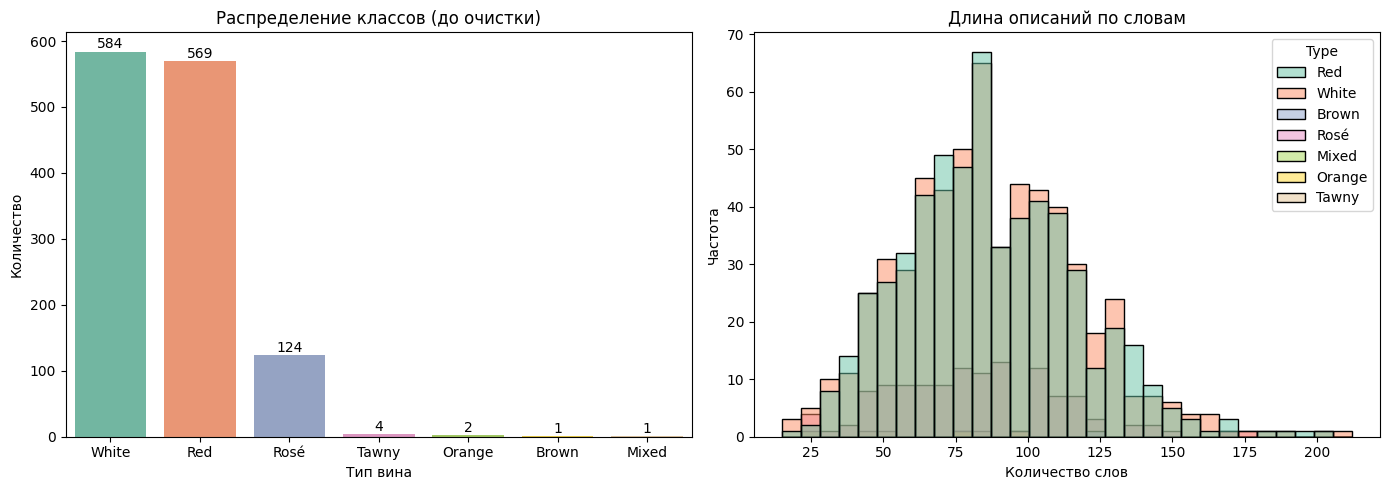

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Type', data=df, ax=axes[0], palette='Set2',
              order=df['Type'].value_counts().index)
axes[0].set_title('Распределение классов (до очистки)')
axes[0].set_xlabel('Тип вина')
axes[0].set_ylabel('Количество')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 int(bar.get_height()),
                 ha='center', fontsize=10)

df['desc_len'] = df['Description'].dropna().apply(lambda x: len(str(x).split()))
sns.histplot(data=df.dropna(), x='desc_len', hue='Type',
             bins=30, ax=axes[1], palette='Set2')
axes[1].set_title('Длина описаний по словам')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
# ensure output directory exists before saving figure
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df.iloc[296][0]

/var/folders/l1/t3rml9dj3c5_2blf8jgn4xg00000gn/T/ipykernel_60954/3607499803.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[296][0]


'Just because it’s inexpensive, doesn’t mean it’s not great quality. This wine is actually made for us by one of the most prestigious winemaking families in Chile, the Arestis. They know how to get the very best peachy, citrussy flavours out of their grapes, while still keeping prices wallet-friendly. The Central Valley, where this wine is from, is cool but has loads of sunshine – so this is more like a ripe white Bordeaux than a full, tropically fruity Kiwi Sauvignon. The fact is, Chilean wines are just incredible value – a wine of this quality from another country could cost far more. In our book, that makes it the ideal party wine. It’s got a real citrussy zing and great tropical flavours. It’s incredibly refreshing, so your guests will be happy to drink it alone, or with finger foods. It’s hard working bottle which won’t disappoint.'

## Очистка данных

In [8]:
def normalize_text(text):
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

In [9]:
def fill_missing_type(df, df_full, row_idx, value):
    if row_idx < 0 or row_idx >= len(df):
        print(f"Индекс {row_idx} вне диапазона")
        return
    original = df_full.iloc[row_idx]['Type']
    print(f"Было: '{original}' → Стало: '{value}'")
    df.loc[df.index[row_idx], 'Type'] = value

In [10]:
fill_missing_type(df, df_full, 667, 'White')

valid_types = ['Red', 'White', 'Rosé']
df = df[df['Type'].isin(valid_types)].copy()
df = df.dropna().copy()

Было: 'nan' → Стало: 'White'


In [11]:
df['Description'] = df['Description'].apply(normalize_text)

label_map = {'Red': 0, 'White': 1, 'Rosé': 2}
df['label'] = df['Type'].map(label_map)

In [12]:
df['Type'].value_counts()

Type
White    584
Red      566
Rosé     124
Name: count, dtype: int64

## Написание классов и методов 

In [13]:
def extract_domain_features(text):
    text_lower = text.lower()
    return [1.0 if word in text_lower else 0.0 for word in CONFIG['domain_words']]

In [14]:
class WineDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.domain_features = [extract_domain_features(t) for t in texts]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=CONFIG['max_len'],
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':       encoding['input_ids'].squeeze(0),
            'attention_mask':  encoding['attention_mask'].squeeze(0),
            'domain_features': torch.tensor(self.domain_features[idx], dtype=torch.float32),
            'label':           torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [15]:
class BertWineClassifier(nn.Module):
    def __init__(self, num_classes, domain_feature_dim):
        super().__init__()
        self.bert = AutoModel.from_pretrained(CONFIG['model_name'])
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + domain_feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_ids, attention_mask, domain_features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        combined = torch.cat([cls_embedding, domain_features], dim=1)
        return self.classifier(combined)

In [16]:
def make_weighted_sampler(labels):
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts
    sample_weights = torch.tensor([weights[l] for l in labels], dtype=torch.float32)
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [17]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        domain_features = batch['domain_features'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, domain_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [18]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            domain_features = batch['domain_features'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, domain_features)
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1, all_preds, all_labels

## Обучение

In [19]:
os.makedirs('plots', exist_ok=True)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

texts = df['Description'].tolist()
labels = df['label'].tolist()

Device: mps


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=labels
)

2026/03/11 21:19:42 INFO mlflow.tracking.fluent: Experiment with name 'wine-bert-classifier' does not exist. Creating a new experiment.
/Users/affiliation/Data_science/Wine-Classifier/.venv/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Epoch 1/3 | Loss: 0.8673 | Accuracy: 67.06% | Macro F1: 0.7043
Epoch 2/3 | Loss: 0.4405 | Accuracy: 83.92% | Macro F1: 0.8463
Epoch 3/3 | Loss: 0.3278 | Accuracy: 89.02% | Macro F1: 0.8928


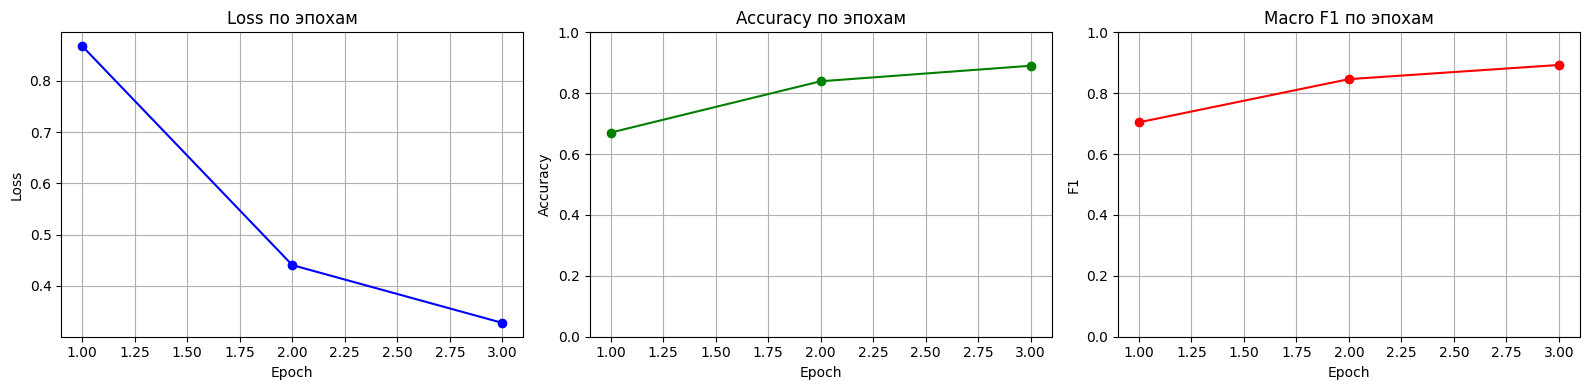

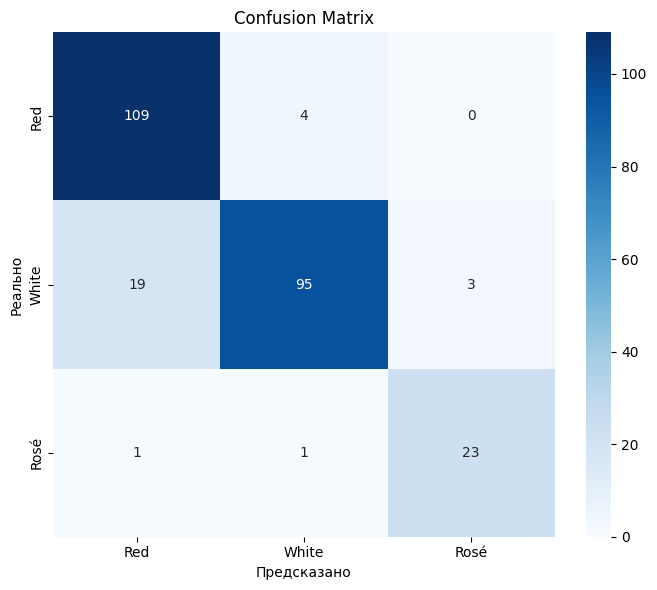

In [21]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

train_dataset = WineDataset(X_train, y_train, tokenizer)
test_dataset  = WineDataset(X_test,  y_test,  tokenizer)

sampler      = make_weighted_sampler(y_train)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], sampler=sampler)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

class_weights        = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion            = nn.CrossEntropyLoss(weight=class_weights_tensor)

mlflow.set_experiment(CONFIG['mlflow_experiment'])

with mlflow.start_run():
    # Логируем все гиперпараметры
    mlflow.log_params(CONFIG)

    model     = BertWineClassifier(CONFIG['num_classes'], len(CONFIG['domain_words'])).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])

    history = {'loss': [], 'accuracy': [], 'f1': []}

    for epoch in range(CONFIG['num_epochs']):
        loss            = train_epoch(model, train_loader, optimizer, criterion, device)
        acc, f1, _, _   = evaluate(model, test_loader, device)

        history['loss'].append(loss)
        history['accuracy'].append(acc)
        history['f1'].append(f1)

        # Логируем метрики в MLflow
        mlflow.log_metric("loss",     loss, step=epoch)
        mlflow.log_metric("accuracy", acc,  step=epoch)
        mlflow.log_metric("macro_f1", f1,   step=epoch)

        print(f"Epoch {epoch+1}/{CONFIG['num_epochs']} | Loss: {loss:.4f} | Accuracy: {acc:.2%} | Macro F1: {f1:.4f}")

    # Финальная оценка с confusion matrix
    _, _, final_preds, final_labels = evaluate(model, test_loader, device)

    # ── ГРАФИК 1: Training curves ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs_range = range(1, CONFIG['num_epochs'] + 1)

    axes[0].plot(epochs_range, history['loss'],     'b-o')
    axes[0].set_title('Loss по эпохам')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)

    axes[1].plot(epochs_range, history['accuracy'], 'g-o')
    axes[1].set_title('Accuracy по эпохам')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].grid(True)

    axes[2].plot(epochs_range, history['f1'],       'r-o')
    axes[2].set_title('Macro F1 по эпохам')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')
    axes[2].set_ylim(0, 1)
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig('plots/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    class_names = ['Red', 'White', 'Rosé']
    cm = confusion_matrix(final_labels, final_preds)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Предсказано')
    plt.ylabel('Реально')
    plt.tight_layout()
    plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


    mlflow.log_artifact('plots/training_curves.png')
    mlflow.log_artifact('plots/confusion_matrix.png')

## Сохранение модели

In [22]:
os.makedirs('wine_model', exist_ok=True)

torch.save(model.state_dict(), 'wine_model/model.pt')
tokenizer.save_pretrained('wine_model/tokenizer')

print("Модель сохранена в wine_model/")

Модель сохранена в wine_model/
